# Notebook 1: Combined Feature Generation

**PronounceAI — Combined Module**

This notebook generates the training dataset for the combined model by:
1. Loading Module 1 (Whisper ASR) and Module 2 (Acoustic models)
2. Iterating over LibriSpeech samples
3. For each sample: computing `module1_score` and `module2_score` for both clean and augmented audio
4. Saving the feature table to `../models/combined_features.csv`

| Column | Description |
|---|---|
| `file` | Audio file path |
| `reference` | Ground-truth transcript |
| `module1_score` | Word-F1 accuracy vs reference (0–100) |
| `module2_score` | Acoustic quality from RF+NN (0–100) |
| `label` | 1=good (clean), 0=degraded (augmented) |

> **Tip:** Set `MAX_FILES = 20` for a fast test run (~10–15 min on CPU).  
> Increase to 50–100 for a better-trained combined model.

## Step 1: Install Dependencies

In [4]:
%pip install librosa numpy pandas matplotlib scikit-learn torch soundfile joblib transformers tqdm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Imports and Paths

In [11]:
import sys
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Add PronounceAI/model/ to path so combined_module is importable
MODEL_DIR = Path('../../').resolve()
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

COMBINED_DIR = Path('../').resolve()
MODELS_DIR   = COMBINED_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

MAX_FILES = 500  # clean files; 30 clean + 30 augmented = 60 total samples

print(f'Model dir       : {MODEL_DIR}')
print(f'Combined module : {COMBINED_DIR}')
print(f'Models output   : {MODELS_DIR}')
print(f'Max files       : {MAX_FILES}')

Model dir       : E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\model
Combined module : E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\model\combined_module
Models output   : E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\model\combined_module\models
Max files       : 500


## Step 3: Load Module 1 and Module 2 Scorers

In [12]:
from combined_module.utils.load_module1 import Module1Scorer
from combined_module.utils.load_module2 import Module2Scorer

print('Loading Module 1 (Whisper)...')
t0 = time.time()
m1 = Module1Scorer()
print(f'  Done in {time.time()-t0:.1f}s  |  device: {m1.device}')

print('Loading Module 2 (RF + NN)...')
t0 = time.time()
m2 = Module2Scorer()
print(f'  Done in {time.time()-t0:.1f}s  |  device: {m2.device}')
print(f'  Feature dim: {m2.input_dim}  |  SR: {m2.sample_rate}')

Loading Module 1 (Whisper)...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

  Done in 0.3s  |  device: cpu
Loading Module 2 (RF + NN)...
  Done in 0.0s  |  device: cpu
  Feature dim: 86  |  SR: 16000


## Step 4: Discover LibriSpeech Files

In [13]:
from combined_module.utils.data_utils import (
    find_audio_files, find_transcript, load_audio, augment_audio
)

# Use train-clean-100 for training data (separate from module_2 which used test-clean)
audio_files = find_audio_files(split='train-clean-100', max_files=MAX_FILES)

# Verify transcripts exist
valid = [(p, find_transcript(p)) for p in audio_files]
valid = [(p, t) for p, t in valid if t]  # drop files with no transcript

print(f'Found {len(audio_files)} audio files, {len(valid)} with transcripts')
if valid:
    print(f'Example: {valid[0][0].name}  ->  "{valid[0][1][:60]}"')

Found 500 audio files, 500 with transcripts
Example: 103-1240-0000.flac  ->  "chapter one missus rachel lynde is surprised missus rachel l"


## Step 5: Generate Combined Features

For each file we create **two rows**:
- **clean** (label=1): scores on the original audio
- **augmented** (label=0): scores on a synthetically degraded version

Expected time: ~7–8 seconds per file pair on CPU (Whisper dominates).

In [14]:
import librosa
import soundfile as sf
import tempfile, os

SR = 16_000
records = []

for path, ref_text in tqdm(valid, desc='Generating features'):
    try:
        y = load_audio(path, sr=SR)
        if len(y) < SR * 0.3:   # skip very short clips
            continue

        # ── Clean sample (label = 1) ───────────────────────────────────────
        m1_clean = m1.score_array(y, ref_text, sr=SR)
        m2_clean = m2.score_array(y)
        records.append({
            'file': str(path), 'reference': ref_text,
            'module1_score': round(m1_clean, 2),
            'module2_score': round(m2_clean, 2),
            'label': 1
        })

        # ── Augmented sample (label = 0) ───────────────────────────────────
        y_aug = augment_audio(y, SR)
        # Save aug to temp file for Module1 transcription
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            sf.write(tmp.name, y_aug, SR)
            tmp_path = tmp.name
        try:
            m1_aug = m1.score(tmp_path, ref_text)
        finally:
            os.remove(tmp_path)
        m2_aug = m2.score_array(y_aug)
        records.append({
            'file': str(path) + '_aug', 'reference': ref_text,
            'module1_score': round(m1_aug, 2),
            'module2_score': round(m2_aug, 2),
            'label': 0
        })

    except Exception as exc:
        print(f'Skipped {path.name}: {exc}')
        continue

df = pd.DataFrame(records)
print(f'\nGenerated {len(df)} samples  ({(df.label==1).sum()} good / {(df.label==0).sum()} degraded)')
df.head(8)

Generating features:   0%|          | 0/500 [00:00<?, ?it/s]


Generated 1000 samples  (500 good / 500 degraded)


,file,reference,module1_score,module2_score,label
0,E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\l...,chapter one missus rachel lynde is surprised m...,100.00,95.61,1
1,E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\l...,chapter one missus rachel lynde is surprised m...,40.68,0.00,0
2,E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\l...,that had its source away back in the woods of ...,100.00,96.15,1
3,E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\l...,that had its source away back in the woods of ...,31.71,0.25,0
4,E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\l...,for not even a brook could run past missus rac...,100.00,97.14,1
5,E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\l...,for not even a brook could run past missus rac...,89.19,51.57,0
6,E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\l...,and that if she noticed anything odd or out of...,100.00,90.83,1
7,E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\l...,and that if she noticed anything odd or out of...,68.29,0.25,0


## Step 6: Save Features to CSV

In [15]:
out_path = MODELS_DIR / 'combined_features.csv'
df.to_csv(out_path, index=False)
print(f'Saved {len(df)} rows to {out_path}')

Saved 1000 rows to E:\UMD\Data_641_PCS1\NLP_project\PronounceAI\model\combined_module\models\combined_features.csv


## Step 7: Summary Statistics and Score Distributions

Score summary by label:
      module1_score                                                    \
              count   mean    std    min     25%    50%    75%    max   
label                                                                   
0             500.0  57.46  27.72   0.00   34.25   56.7   82.4  100.0   
1             500.0  99.59   1.43  82.35  100.00  100.0  100.0  100.0   

      module2_score                                                   
              count   mean    std    min    25%    50%    75%    max  
label                                                                 
0             500.0  10.66  18.11   0.00   0.25   2.25  12.91  91.91  
1             500.0  93.47   8.14  16.81  92.65  95.26  97.13  99.11  


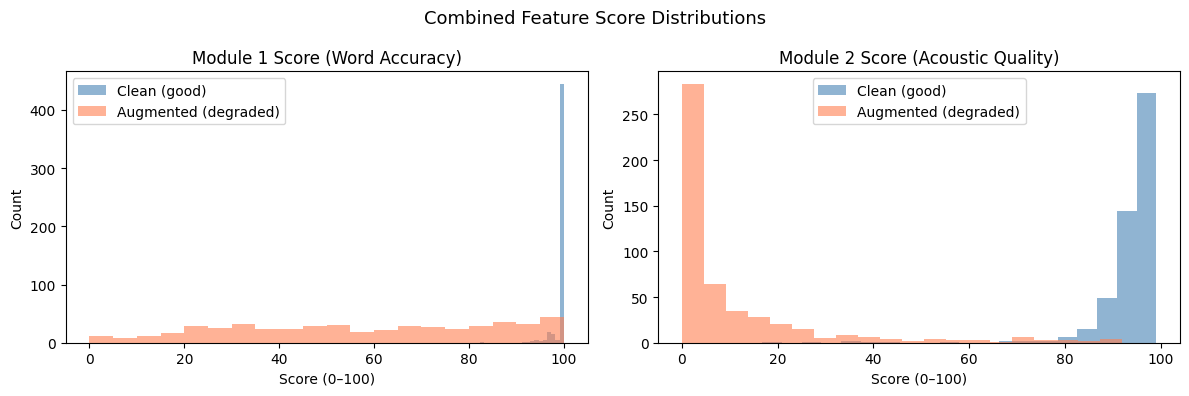

Distribution plot saved.


In [16]:
print('Score summary by label:')
print(df.groupby('label')[['module1_score', 'module2_score']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [
    (axes[0], 'module1_score', 'Module 1 Score (Word Accuracy)'),
    (axes[1], 'module2_score', 'Module 2 Score (Acoustic Quality)'),
]:
    ax.hist(df[df.label==1][col], bins=20, alpha=0.6, color='steelblue', label='Clean (good)')
    ax.hist(df[df.label==0][col], bins=20, alpha=0.6, color='coral',     label='Augmented (degraded)')
    ax.set_title(title); ax.set_xlabel('Score (0–100)'); ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Combined Feature Score Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'combined_feature_distributions.png', dpi=120)
plt.show()
print('Distribution plot saved.')